## Operator Benchmarks

Each row checks forward and backward correctness against `TorchOpsBackend`, then reports forward/backward p50 latency, p95 latency, peak CUDA memory delta, and speedup versus torch.


In [1]:
from pathlib import Path
import sys

import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "minitrain").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "tests"))

from minitrain.model.ops import get_ops_backend
from operator_bench_utils import BenchCase, bench_sweep, plot_kernel_grid, to_summary_dataframe

torch.manual_seed(0)
assert torch.cuda.is_available(), "operator benchmarks require CUDA"

DEVICE = torch.device("cuda")
DTYPE = torch.float16
PROVIDERS = ("torch", "triton", "cuda")
WARMUP_MS = 25
REP_MS = 100
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
METRICS = (
    "fwd_p50_ms",
    "fwd_p95_ms",
    "fwd_peak_mem_mb",
    "fwd_speedup",
    "bwd_p50_ms",
    "bwd_p95_ms",
    "bwd_peak_mem_mb",
    "bwd_speedup",
)

print(torch.__version__)
print(torch.cuda.get_device_name(0))


2.5.1+cu121
NVIDIA GeForce RTX 3050 Laptop GPU


Each kernel section now provides `make_case(size)` and `forward(provider, tensors)`. The runner owns tensor cloning, forward/backward correctness, timing, memory measurement, and cleanup. Cleanup clears the torch-created tensor dictionary before releasing the CUDA cache.

In [2]:
def run_kernel(kernel, sizes, size_label, make_case, forward):
    rows = bench_sweep(
        kernel=kernel,
        providers=PROVIDERS,
        sizes=sizes,
        size_label=size_label,
        make_case=make_case,
        forward=forward,
        warmup_ms=WARMUP_MS,
        rep_ms=REP_MS,
    )
    display(to_summary_dataframe(rows))
    plot_kernel_grid(rows, metrics=METRICS, save_path=FIG_DIR / f"{kernel}_summary.png")
    return rows


## RMSNorm

Sweep parameter: `rows`.

X-axis: activation tensor elements, `rows * hidden`.

,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,rmsnorm,torch,16384,ok,True,True,0.000000,0.000000,0.033792,0.034816,0.125000,1.000000,0.601696,1.178685,0.250000,1.000000
1,rmsnorm,triton,16384,ok,True,True,0.001953,0.015625,0.006144,0.006144,0.031738,5.500000,0.342048,0.449280,0.080078,1.759098
2,rmsnorm,torch,32768,ok,True,True,0.000000,0.000000,0.027648,0.029696,0.250000,1.000000,0.592896,1.148366,0.500000,1.000000
3,rmsnorm,triton,32768,ok,True,True,0.001953,0.015625,0.005120,0.006144,0.062988,5.400000,0.376368,0.509910,0.142578,1.575309
4,rmsnorm,torch,65536,ok,True,True,0.000000,0.000000,0.028672,0.030720,0.500000,1.000000,0.541584,1.111806,0.999512,1.000000
5,rmsnorm,triton,65536,ok,True,True,0.003906,0.031250,0.007168,0.008192,0.125977,4.000000,0.410000,0.644198,0.267578,1.320937
6,rmsnorm,torch,131072,ok,True,True,0.000000,0.000000,0.035840,0.037888,1.000000,1.000000,0.535056,1.071229,1.998047,1.000000
7,rmsnorm,triton,131072,ok,True,True,0.003906,0.031250,0.008192,0.009216,0.251953,4.375000,0.351744,0.446720,0.517578,1.521152
8,rmsnorm,torch,262144,ok,True,True,0.000000,0.000000,0.052224,0.054272,2.000000,1.000000,0.573440,0.982923,3.995117,1.000000
9,rmsnorm,triton,262144,ok,True,True,0.001953,0.062500,0.011264,0.011264,0.503906,4.636364,0.397440,0.644352,1.017578,1.442834


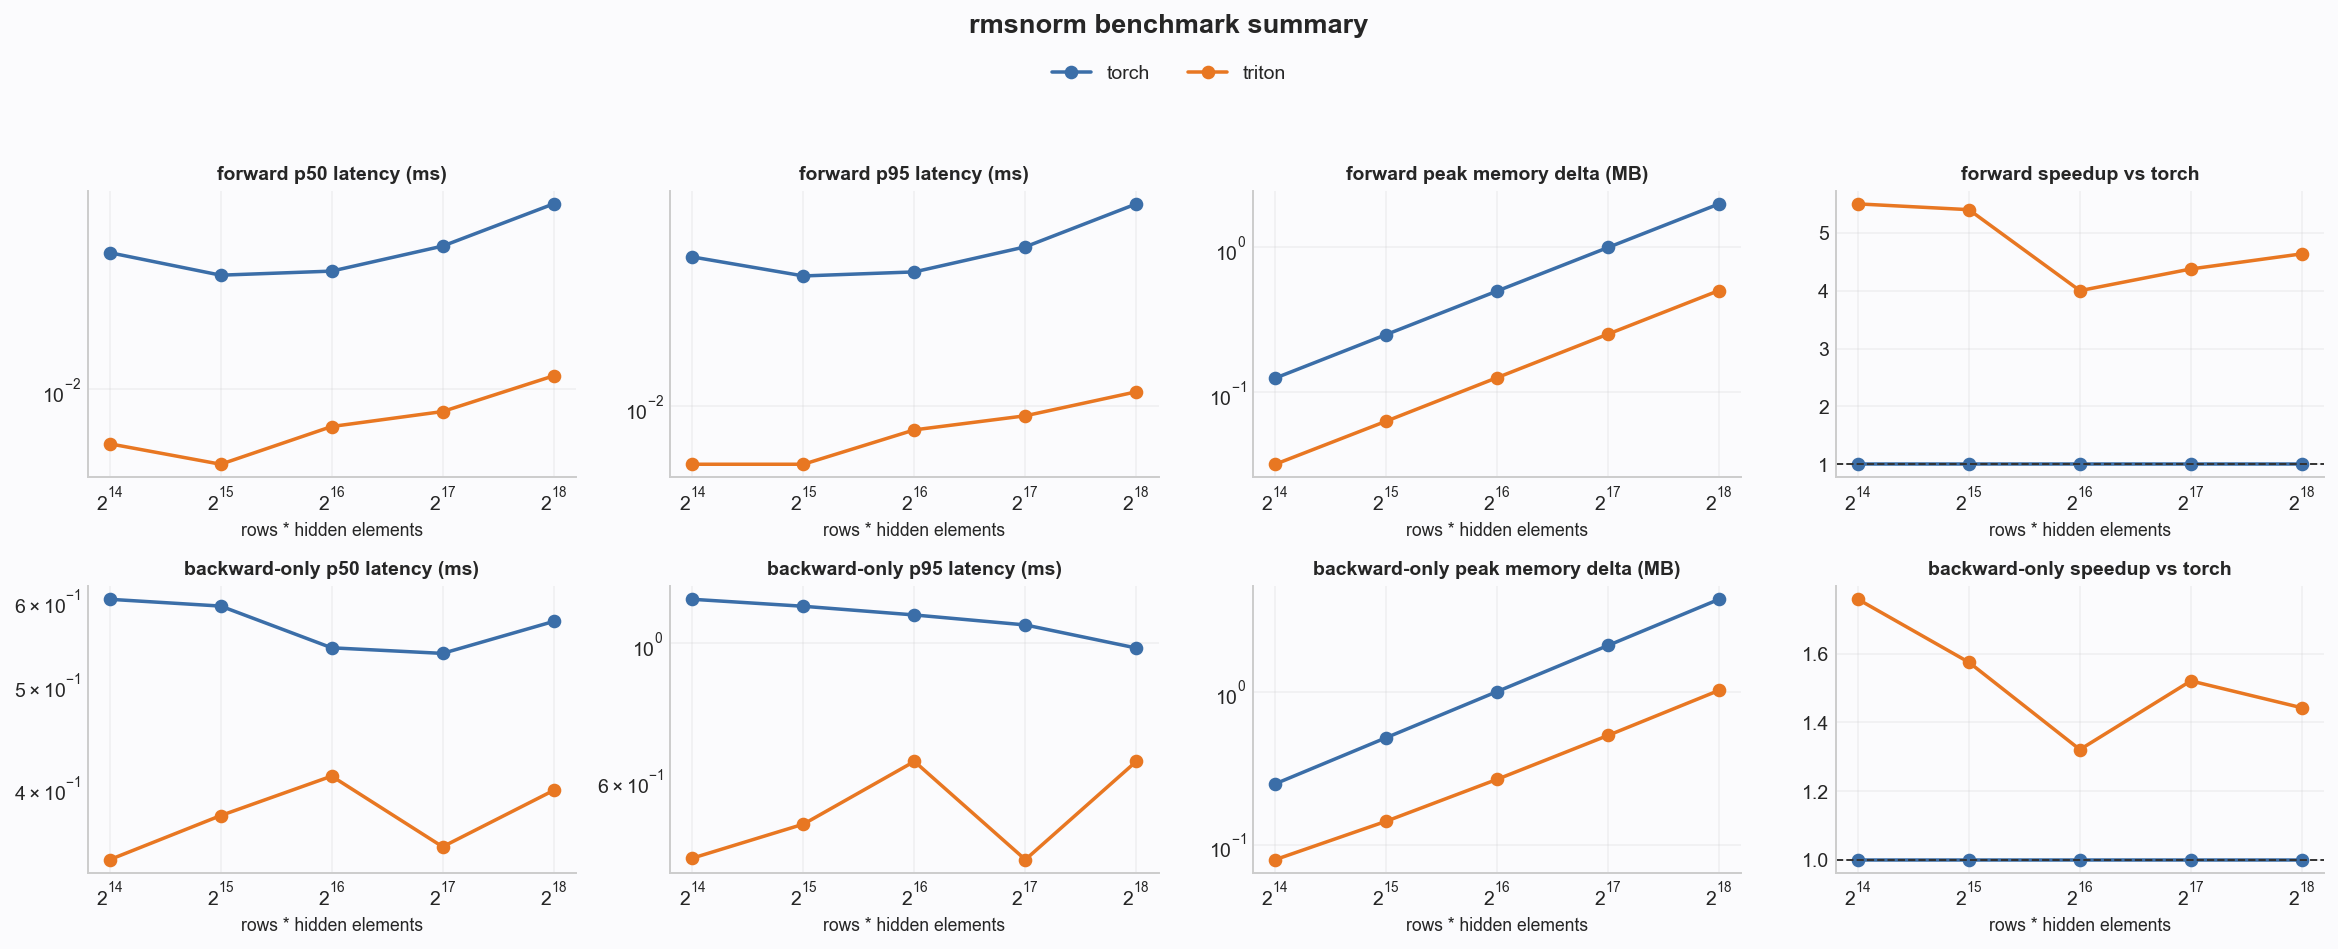

In [3]:
PROVIDERS = ("torch", "triton")
def make_rmsnorm_case(size):
    hidden = 256
    rows = size // hidden
    return BenchCase(
        tensors={
            "x": torch.randn(rows, hidden, device=DEVICE, dtype=DTYPE),
            "weight": torch.ones(hidden, device=DEVICE, dtype=DTYPE),
        },
        grad_names=("x", "weight"),
    )


def rmsnorm_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.rmsnorm(tensors["x"], tensors["weight"], 1e-5)


rmsnorm_sizes = [256 * rows for rows in (64, 128, 256, 512, 1024)]
rmsnorm_rows = run_kernel(
    "rmsnorm",
    rmsnorm_sizes,
    "rows * hidden elements",
    make_rmsnorm_case,
    rmsnorm_forward,
)

## RoPE

Sweep parameter: `seq`.

X-axis: Q+K tensor elements, `2 * batch * heads * seq * head_dim`.

,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,rope,torch,16384,ok,True,True,0.000000,0.0,0.096320,0.156544,0.06250,1.000000,0.701968,1.071720,0.078613,1.000000
1,rope,triton,16384,ok,True,True,0.001953,0.0,0.005120,0.006144,0.03125,18.812501,0.406464,0.475443,0.062988,1.727011
2,rope,torch,32768,ok,True,True,0.000000,0.0,0.109568,0.158720,0.12500,1.000000,0.628736,0.975104,0.156738,1.000000
3,rope,triton,32768,ok,True,True,0.001953,0.0,0.006144,0.008090,0.06250,17.833333,0.431568,0.523878,0.125488,1.456864
4,rope,torch,65536,ok,True,True,0.000000,0.0,0.094208,0.126464,0.25000,1.000000,0.581680,0.622694,0.312988,1.000000
5,rope,triton,65536,ok,True,True,0.001953,0.0,0.006144,0.007168,0.12500,15.333333,0.349696,0.378880,0.250488,1.663388
6,rope,torch,131072,ok,True,True,0.000000,0.0,0.089088,0.129024,0.50000,1.000000,0.581184,0.669850,0.625488,1.000000
7,rope,triton,131072,ok,True,True,0.003906,0.0,0.008192,0.009216,0.25000,10.875000,0.348672,0.387226,0.500488,1.666850
8,rope,torch,262144,ok,True,True,0.000000,0.0,0.086528,0.130390,1.00000,1.000000,0.588240,0.777472,1.250488,1.000000
9,rope,triton,262144,ok,True,True,0.001953,0.0,0.011264,0.012288,0.50000,7.681818,0.354304,0.488642,1.000488,1.660269


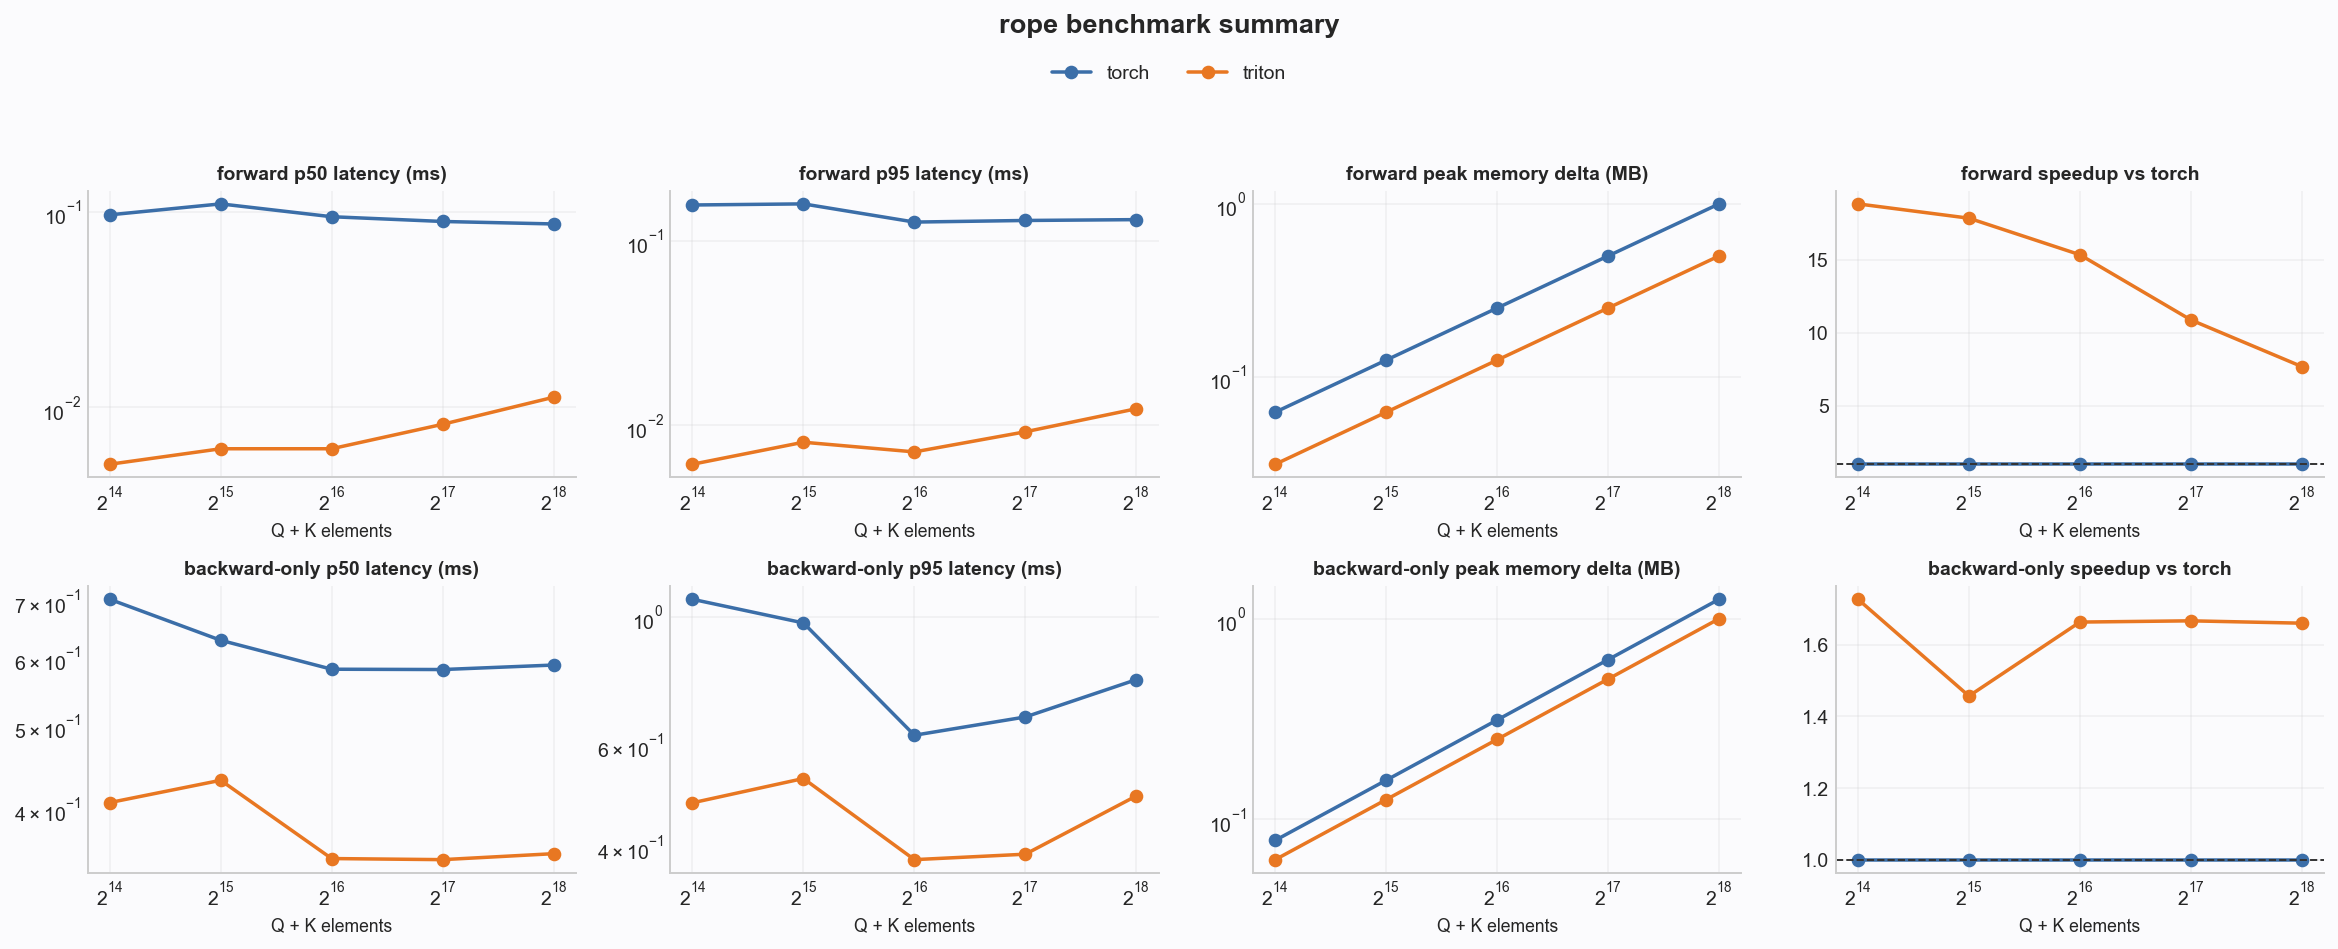

In [4]:
PROVIDERS = ("torch", "triton")
def rope_cache(seq, dim):
    inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2, device=DEVICE).float() / dim))
    freqs = torch.outer(torch.arange(seq, device=DEVICE).float(), inv_freq)
    emb = torch.cat((freqs, freqs), dim=-1)
    return emb.cos().to(dtype=DTYPE), emb.sin().to(dtype=DTYPE)


def make_rope_case(size):
    batch, heads, head_dim = 1, 4, 64
    seq = size // (2 * batch * heads * head_dim)
    cos, sin = rope_cache(seq, head_dim)
    return BenchCase(
        tensors={
            "q": torch.randn(batch, heads, seq, head_dim, device=DEVICE, dtype=DTYPE),
            "k": torch.randn(batch, heads, seq, head_dim, device=DEVICE, dtype=DTYPE),
            "cos": cos,
            "sin": sin,
        },
        grad_names=("q", "k"),
    )


def rope_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.rope(tensors["q"], tensors["k"], tensors["cos"], tensors["sin"])


rope_sizes = [2 * 1 * 4 * seq * 64 for seq in (32, 64, 128, 256, 512)]
rope_rows = run_kernel("rope", rope_sizes, "Q + K elements", make_rope_case, rope_forward)


## SwiGLU

Sweep parameter: `rows`.

X-axis: input tensor elements, `2 * rows * intermediate` for gate and up.

,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,swiglu,torch,65536,ok,True,True,0.000000,0.000000,0.010240,0.011264,0.1250,1.000000,0.222800,0.292301,0.187988,1.000000
1,swiglu,triton,65536,ok,True,True,0.000000,0.000977,0.006144,0.007168,0.0625,1.666667,0.321024,0.350232,0.187988,0.694029
2,swiglu,torch,131072,ok,True,True,0.000000,0.000000,0.010240,0.011264,0.2500,1.000000,0.236608,0.272538,0.375488,1.000000
3,swiglu,triton,131072,ok,True,True,0.000244,0.000488,0.007168,0.007894,0.1250,1.428571,0.278048,0.337050,0.375488,0.850961
4,swiglu,torch,262144,ok,True,True,0.000000,0.000000,0.012304,0.014336,0.5000,1.000000,0.212464,0.247245,0.750488,1.000000
5,swiglu,triton,262144,ok,True,True,0.000122,0.000488,0.009216,0.009230,0.2500,1.335069,0.407552,0.703747,0.750488,0.521318
6,swiglu,torch,524288,ok,True,True,0.000000,0.000000,0.018432,0.019456,1.0000,1.000000,0.234496,0.291891,1.500488,1.000000
7,swiglu,triton,524288,ok,True,True,0.000244,0.001953,0.013312,0.014336,0.5000,1.384615,0.303616,0.375296,1.500488,0.772344
8,swiglu,torch,1048576,ok,True,True,0.000000,0.000000,0.033792,0.035840,2.0000,1.000000,0.209376,0.279597,3.000488,1.000000
9,swiglu,triton,1048576,ok,True,True,0.000244,0.000977,0.022528,0.022960,1.0000,1.500000,0.257552,0.351840,3.000488,0.812946


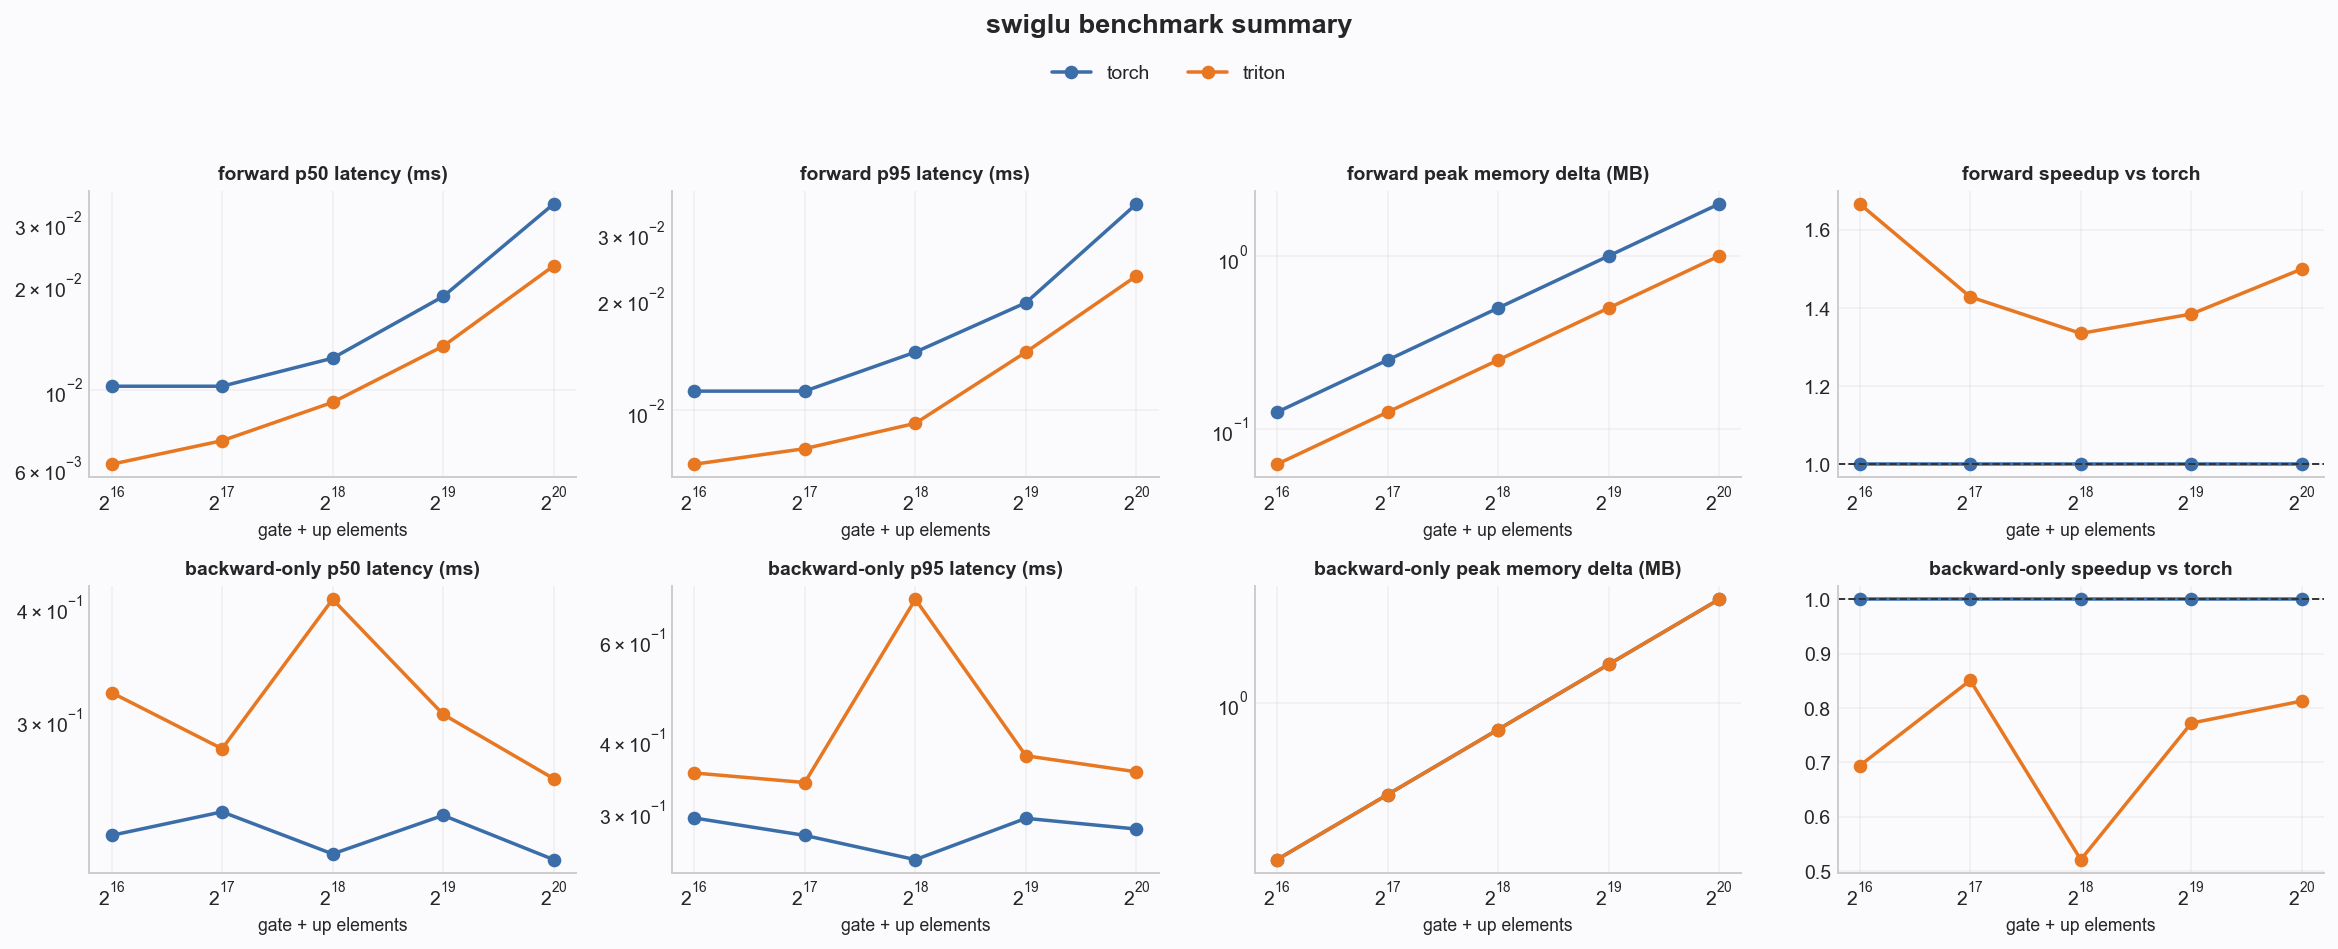

In [6]:
PROVIDERS = ("torch", "triton")
def make_swiglu_case(size):
    intermediate = 512
    rows = size // (2 * intermediate)
    return BenchCase(
        tensors={
            "gate": torch.randn(rows, intermediate, device=DEVICE, dtype=DTYPE),
            "up": torch.randn(rows, intermediate, device=DEVICE, dtype=DTYPE),
        },
        grad_names=("gate", "up"),
    )


def swiglu_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.swiglu(tensors["gate"], tensors["up"])


swiglu_sizes = [2 * rows * 512 for rows in (64, 128, 256, 512, 1024)]
swiglu_rows = run_kernel(
    "swiglu",
    swiglu_sizes,
    "gate + up elements",
    make_swiglu_case,
    swiglu_forward,
)


## CrossEntropy

Sweep parameter: `tokens`.

X-axis: logits tensor elements, `tokens * vocab`.

In [ ]:
def make_cross_entropy_case(size):
    vocab = 1024
    tokens = size // vocab
    return BenchCase(
        tensors={
            "logits": torch.randn(tokens, vocab, device=DEVICE, dtype=DTYPE),
            "targets": torch.randint(vocab, (tokens,), device=DEVICE),
        },
        grad_names=("logits",),
    )


def cross_entropy_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.cross_entropy(tensors["logits"], tensors["targets"])


cross_entropy_sizes = [tokens * 1024 for tokens in (64, 128, 256, 512, 1024)]
cross_entropy_rows = run_kernel(
    "cross_entropy",
    cross_entropy_sizes,
    "tokens * vocab logits elements",
    make_cross_entropy_case,
    cross_entropy_forward,
)


## FusedLinearCrossEntropy

Sweep parameter: `vocab`.

X-axis: logical logits elements, `tokens * vocab`. This is the tensor a fused implementation tries not to materialize.

In [ ]:
def make_fused_linear_ce_case(size):
    tokens, hidden = 128, 256
    vocab = size // tokens
    return BenchCase(
        tensors={
            "x": torch.randn(tokens, hidden, device=DEVICE, dtype=DTYPE),
            "weight": torch.randn(vocab, hidden, device=DEVICE, dtype=DTYPE),
            "targets": torch.randint(vocab, (tokens,), device=DEVICE),
        },
        grad_names=("x", "weight"),
    )


def fused_linear_ce_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.fused_linear_cross_entropy(tensors["x"], tensors["weight"], tensors["targets"])


fused_linear_ce_sizes = [128 * vocab for vocab in (512, 1024, 2048, 4096, 8192)]
fused_linear_ce_rows = run_kernel(
    "fused_linear_cross_entropy",
    fused_linear_ce_sizes,
    "tokens * vocab logical logits elements",
    make_fused_linear_ce_case,
    fused_linear_ce_forward,
)


## FlashAttention / PyTorch SDPA

Bench MiniTrain's attention path and print the PyTorch SDPA backend selected for the same benchmark shapes.


PyTorch SDPA backend selection:
  is_causal=True, dropout_p=0.0
  shape=(2, 4, 1024, 128) -> memory_efficient_attention
  shape=(2, 4, 4096, 128) -> memory_efficient_attention
  shape=(2, 4, 16384, 128) -> memory_efficient_attention
  shape=(2, 4, 65536, 128) -> memory_efficient_attention


,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,attention,torch,3145728,ok,True,True,0.000000,0.000122,0.295936,0.312211,2.00000,1.000000,2.291200,2.734131,22.035645,1.000000
1,attention,triton,3145728,ok,True,True,0.000488,0.003906,0.228352,0.230400,2.03125,1.295964,1.017856,1.093981,12.031738,2.251006
2,attention,torch,12582912,ok,True,True,0.000000,0.000244,3.761664,4.455782,8.00000,1.000000,27.744256,28.300748,68.641113,1.000000
3,attention,triton,12582912,ok,True,True,0.000488,0.001953,2.571264,2.886503,8.12500,1.462963,9.763728,10.116966,48.125488,2.841564
4,attention,torch,50331648,ok,True,True,0.000000,0.000244,61.156353,61.156353,32.00000,1.000000,452.019196,455.181918,237.062988,1.000000
5,attention,triton,50331648,ok,True,True,0.000488,0.003906,39.687679,39.948032,32.50000,1.540941,137.130493,138.203246,192.500488,3.296270
6,attention,torch,201326592,ok,True,True,0.000000,0.000122,953.984009,953.984009,128.00000,1.000000,7255.347168,7270.505908,910.750488,1.000000
7,attention,triton,201326592,ok,True,True,0.000488,0.003906,610.959351,610.959351,130.00000,1.561453,2182.477905,2193.983679,770.000488,3.324362


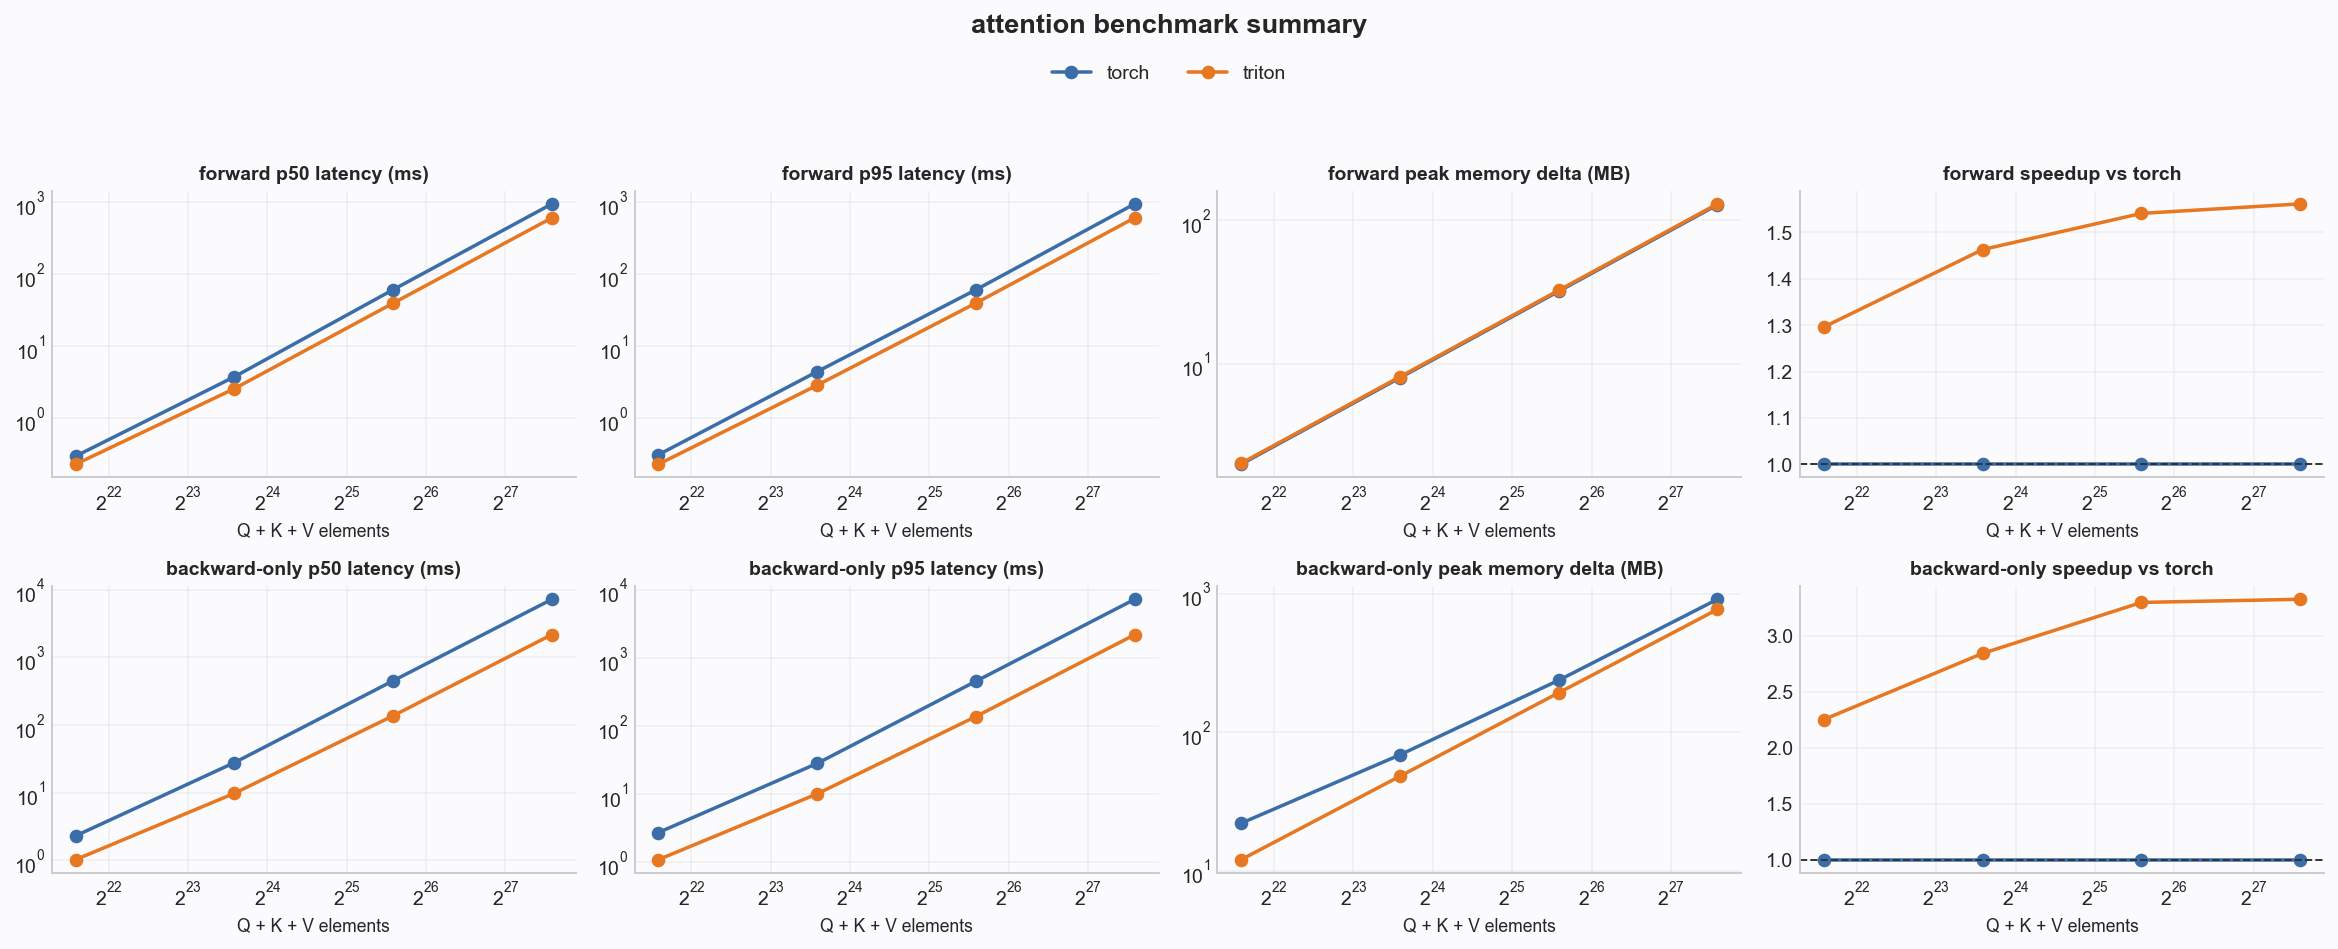

In [7]:
import torch.nn.functional as F
from torch.profiler import ProfilerActivity

PROVIDERS = ("torch", "triton")

ATTENTION_BATCH = 2
ATTENTION_HEADS = 4
ATTENTION_HEAD_DIM = 128
ATTENTION_SEQS = (1024, 1024*4, 1024*16, 1024*64)
ATTENTION_IS_CAUSAL = True
ATTENTION_DROPOUT_P = 0.0

SDPA_ATEN_BACKENDS = (
    ("aten::_scaled_dot_product_flash_attention", "flash_attention"),
    ("aten::_scaled_dot_product_efficient_attention", "memory_efficient_attention"),
    ("aten::_scaled_dot_product_cudnn_attention", "cudnn_attention"),
    ("aten::_scaled_dot_product_attention_math", "math"),
)


def detect_pytorch_sdpa_backend(q, k, v, *, is_causal, dropout_p):
    activities = [ProfilerActivity.CPU]
    if q.is_cuda:
        activities.append(ProfilerActivity.CUDA)
        torch.cuda.synchronize()

    with torch.profiler.profile(activities=activities) as prof:
        with torch.no_grad():
            F.scaled_dot_product_attention(
                q,
                k,
                v,
                is_causal=is_causal,
                dropout_p=dropout_p,
            )
        if q.is_cuda:
            torch.cuda.synchronize()

    event_keys = {event.key for event in prof.key_averages()}
    for aten_name, backend_name in SDPA_ATEN_BACKENDS:
        if aten_name in event_keys:
            return backend_name

    sdpa_events = sorted(
        key for key in event_keys if "scaled_dot_product" in key or "sdp" in key.lower()
    )
    return "unknown: " + ", ".join(sdpa_events[:6])


def attention_size(seq):
    return 3 * ATTENTION_BATCH * ATTENTION_HEADS * seq * ATTENTION_HEAD_DIM


def make_attention_case(size):
    seq = size // (3 * ATTENTION_BATCH * ATTENTION_HEADS * ATTENTION_HEAD_DIM)
    return BenchCase(
        tensors={
            "q": torch.randn(
                ATTENTION_BATCH,
                ATTENTION_HEADS,
                seq,
                ATTENTION_HEAD_DIM,
                device=DEVICE,
                dtype=DTYPE,
            ),
            "k": torch.randn(
                ATTENTION_BATCH,
                ATTENTION_HEADS,
                seq,
                ATTENTION_HEAD_DIM,
                device=DEVICE,
                dtype=DTYPE,
            ),
            "v": torch.randn(
                ATTENTION_BATCH,
                ATTENTION_HEADS,
                seq,
                ATTENTION_HEAD_DIM,
                device=DEVICE,
                dtype=DTYPE,
            ),
        },
        grad_names=("q", "k", "v"),
    )


def attention_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.attention(
        tensors["q"],
        tensors["k"],
        tensors["v"],
        is_causal=ATTENTION_IS_CAUSAL,
        dropout_p=ATTENTION_DROPOUT_P,
    )


def print_sdpa_backend_report(sizes):
    print("PyTorch SDPA backend selection:")
    print(f"  is_causal={ATTENTION_IS_CAUSAL}, dropout_p={ATTENTION_DROPOUT_P}")
    for size in sizes:
        case = make_attention_case(size)
        q, k, v = case.tensors["q"], case.tensors["k"], case.tensors["v"]
        backend = detect_pytorch_sdpa_backend(
            q,
            k,
            v,
            is_causal=ATTENTION_IS_CAUSAL,
            dropout_p=ATTENTION_DROPOUT_P,
        )
        print(f"  shape={tuple(q.shape)} -> {backend}")
        del case, q, k, v
        torch.cuda.empty_cache()


attention_sizes = [attention_size(seq) for seq in ATTENTION_SEQS]
print_sdpa_backend_report(attention_sizes)
attention_rows = run_kernel(
    "attention",
    attention_sizes,
    "Q + K + V elements",
    make_attention_case,
    attention_forward,
)

attention_summary = to_summary_dataframe(attention_rows)
attention_failures = attention_summary[attention_summary["status"] != "ok"]
if len(attention_failures):
    display(attention_failures[["provider", "size", "status", "error"]])


In [4]:
attention_rows

[{'kernel': 'attention',
  'provider': 'torch',
  'size': 196608,
  'size_label': 'Q + K + V elements',
  'status': 'ok',
  'fwd_correct': True,
  'fwd_max_abs': 0.0,
  'fwd_max_rel': 0.0,
  'bwd_correct': True,
  'bwd_max_abs': 0.0,
  'bwd_max_rel': 0.0,
  'fwd_p50_ms': 0.016383999958634377,
  'fwd_p95_ms': 0.01740800030529499,
  'fwd_peak_mem_mb': 0.125,
  'timer': 'cuda_events_backward_only',
  'bwd_p50_ms': 0.28571200370788574,
  'bwd_p95_ms': 0.4499967858195306,
  'bwd_peak_mem_mb': 0.8798828125,
  'fwd_speedup': 1.0,
  'bwd_speedup': 1.0},
 {'kernel': 'attention',
  'provider': 'triton',
  'size': 196608,
  'size_label': 'Q + K + V elements',
  'status': 'unavailable',
  'error': 'CompilationError: at 189:13:\n    # Compute dQ for one Q row block.\n    start_m = pid * BLOCK_M\n    offs_m = start_m + tl.arange(0, BLOCK_M)\n    q = tl.load(Q + offs_m[:, None] * stride_qm + offs_d[None, :], mask=(offs_m[:, None] < seqlen_q) & (offs_d[None, :] < headdim), other=0.0)\n    do = tl.load